In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df_processed = pd.read_pickle("dataframes/df_processed.pkl")

In [22]:
# Add Europe-wide totals (sums across all countries) per year
# 1) Identify numeric columns to aggregate (exclude 'year' which is the group key)
numeric_cols = [
    c for c in df_processed.select_dtypes(include="number").columns
    if c != "year"
]

# 2) Aggregate by year
df_totals = (
    df_processed
    .groupby("year")[numeric_cols]
    .sum()
    .reset_index()
 )

# 3) Set geo and country to TOTAL for these aggregate rows
df_totals["geo"] = "TOTAL"
df_totals["country"] = "TOTAL"

# 4) Align column order with original df_processed
df_totals = df_totals[df_processed.columns]

# 5) Append the TOTAL rows back to df_processed
df_processed = pd.concat([df_processed, df_totals], ignore_index=True)

# Optional: quick check of the new TOTAL rows
display(df_processed[df_processed["geo"] == "TOTAL"].sort_values("year"))

,geo,year,asylum_applicants,population,asylum_per_100k,country,ICCS0101,ICCS0301,ICCS03011,ICCS0401,ICCS0502,crime_per_100k
290,TOTAL,2013,395335.0,454830270.0,3256.531720,TOTAL,41.47,975.91,302.91,1924.97,46102.80,49348.06
291,TOTAL,2014,564055.0,455516765.0,4002.436784,TOTAL,39.22,912.62,305.71,1691.02,43951.01,46899.58
292,TOTAL,2015,1285805.0,456328333.0,9435.335199,TOTAL,41.01,919.20,309.20,1557.19,41102.01,43928.61
293,TOTAL,2016,1196225.0,457544379.0,5088.290652,TOTAL,36.62,990.05,359.96,1446.69,38329.86,41163.18
294,TOTAL,2017,640515.0,458348472.0,3879.743462,TOTAL,36.46,1024.58,377.94,1338.24,36558.49,39335.71
295,TOTAL,2018,580990.0,459081125.0,4116.416081,TOTAL,34.41,1077.41,415.79,1259.54,33680.96,36468.11
296,TOTAL,2019,644040.0,460022663.0,5349.866843,TOTAL,32.23,1110.02,436.38,1249.69,32987.37,35815.69
297,TOTAL,2020,426565.0,461003637.0,3284.315532,TOTAL,33.97,1088.35,431.49,1036.55,28048.08,30638.44
298,TOTAL,2021,551185.0,459952680.0,4512.197685,TOTAL,30.18,1258.00,503.32,975.93,26313.44,29080.87
299,TOTAL,2022,901805.0,460162989.0,7699.574769,TOTAL,31.16,1296.28,524.67,1075.26,30989.37,33916.74


In [23]:
crime_codes = {
    'ICCS0101': 'Intentional homicide',
    'ICCS0301': 'Sexual violence',
    'ICCS03011': 'Rape',
    'ICCS0401': 'Robbery',
    'ICCS0502': 'Theft',
}

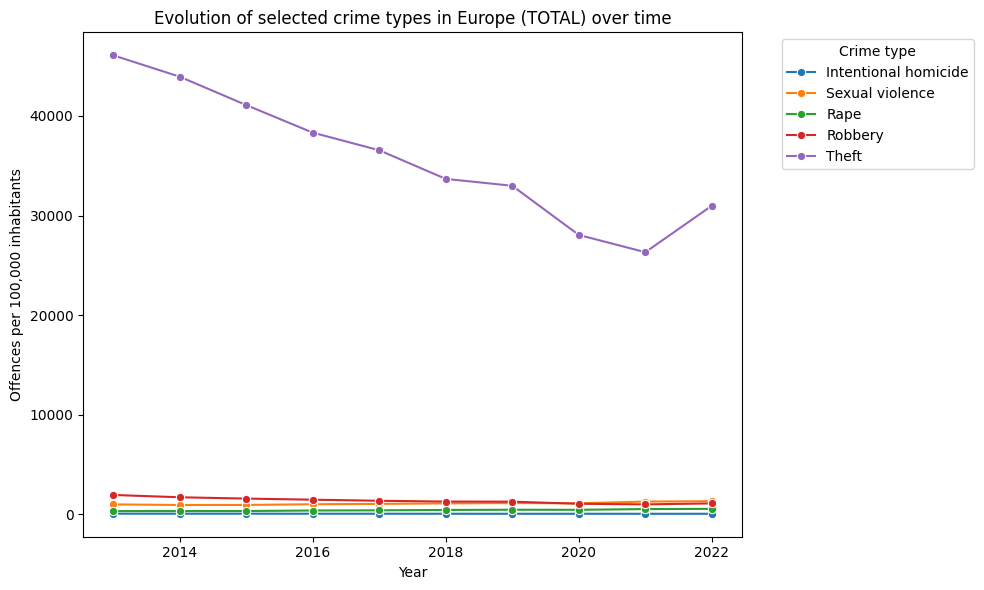

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to Europe-wide totals (geo == 'TOTAL')
df_eu = df_processed[df_processed["geo"] == "TOTAL"].copy()

# Keep only year and selected crime-code columns
crime_cols = list(crime_codes.keys())
cols_for_plot = ["year"] + crime_cols
df_eu_subset = df_eu[cols_for_plot].copy()

# Reshape to long format: one row per (year, crime code)
df_eu_long = df_eu_subset.melt(
    id_vars="year",
    value_vars=crime_cols,
    var_name="iccs",
    value_name="crime_rate_per_100k"
)

# Map ICCS codes to descriptive crime names for nicer labels
df_eu_long["crime_type"] = df_eu_long["iccs"].map(crime_codes)

# Create 5 subplots, one for each crime type
unique_crimes = crime_cols
n_crimes = len(unique_crimes)
fig, axes = plt.subplots(n_crimes, 1, figsize=(10, 2.5 * n_crimes), sharex=True)

# If only one crime, axes may not be an array
if n_crimes == 1:
    axes = [axes]

for ax, iccs_code in zip(axes, unique_crimes):
    crime_name = crime_codes.get(iccs_code, iccs_code)
    data_sub = df_eu_long[df_eu_long["iccs"] == iccs_code]
    sns.lineplot(
        data=data_sub,
        x="year",
        y="crime_rate_per_100k",
        marker="o",
        ax=ax,
    )
    ax.set_title(crime_name)
    ax.set_ylabel("per 100k inhabitants")

axes[-1].set_xlabel("Year")
plt.suptitle("Evolution of selected crime types in Europe (TOTAL) over time", y=1.02)
plt.tight_layout()
plt.show()